In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

## Problem *5.2

### (a)

\begin{align*}
Y[z] &= bX[z] - 0.81z^{-2}Y[z]\\
Y[z] + 0.81z^{-2}Y[z] &= bX[z]\\
H[z] = \frac{Y[z]}{X[z]} &= \frac{b}{1 + 0.81 z^{-2}}\\
H(e^{ j\omega }) &= \frac{b}{1 + 0.81 e^{ -2j\omega }}, \quad z = e^{j \omega}
\end{align*}

### (b)

\begin{align*}
|H(e^{ j\omega })| &= 1\\
\frac{|b|}{|1 + 0.81 e^{ -2j\omega }|} &= 1\\
|b| &= |1 + 0.81e^{ -2j\omega }|\\
|b| &= \sqrt{ (1 + 0.81 \cos(2\omega))^{2} + (0.81 \sin(2\omega))^{2} }\\
|b| &= \sqrt{ 1 + 2 \cdot 0.81 \cos(2\omega) + 0.81^{2} \cos(2\omega)^{2} + 0.81^{2} \sin(2\omega)^{2} }\\
|b| &= \sqrt{ 1 + 1.62 \cos(2\omega) + 0.81^{2} }
\end{align*}

Since the right hand side corresponds to the denominator of the frequency response the magnitude will be at its maximum when the right hand side is minimized. Doing this makes sure that the value of $|H(e^{j \omega})|$ won't go beyond 1. It is minimized when $\cos(2\omega) = -1$ or $\omega=\frac{\pi}{2}$. Plotting this into the equation gives a b-value of
$$
b = \sqrt{ 1 + 1.62 \cos\left( 2 \frac{\pi}{2} \right) + 0.81^{2} } = 0.19
$$

Text(0, 0.5, 'Magnitude')

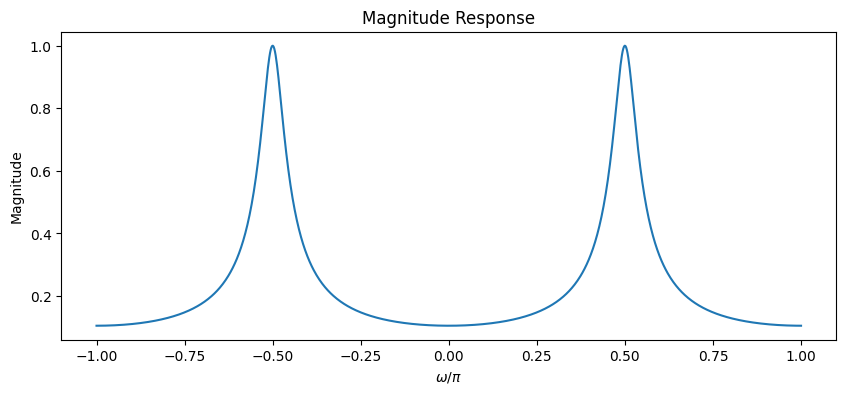

In [5]:
b = 0.19
w = np.linspace(-np.pi, np.pi, 1000)
num = [b]  # Numerator coefficients
den = [1, 0, 0.81]  # Denominator coefficients
_, H = signal.freqz(num, den, worN=w)

plt.figure(figsize=(10, 4))
plt.plot(w/np.pi, np.abs(H))
plt.title("Magnitude Response")
plt.xlabel("$\omega / \pi$")
plt.ylabel("Magnitude")

### (c)

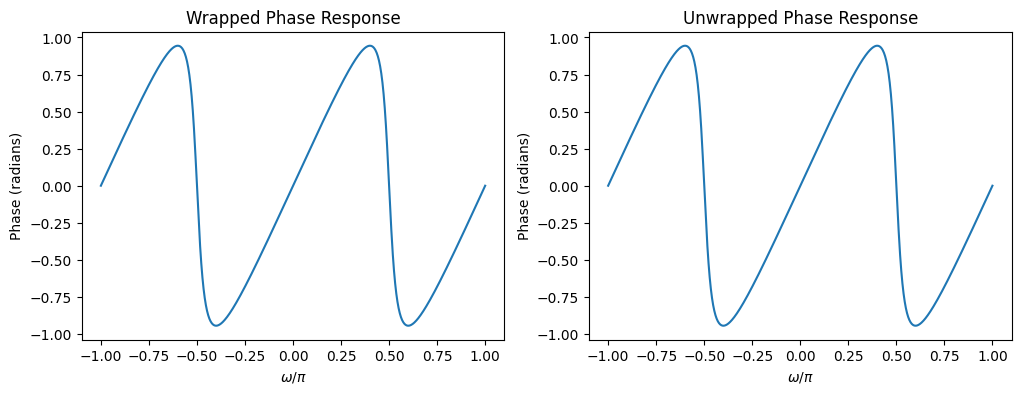

In [6]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(w / np.pi, np.angle(H))
plt.xlabel("$\omega / \pi$")
plt.ylabel("Phase (radians)")
plt.title("Wrapped Phase Response")

plt.subplot(1, 2, 2)
plt.plot(w / np.pi, np.unwrap(np.angle(H)))
plt.xlabel("$\omega / \pi$")
plt.ylabel("Phase (radians)")
plt.title("Unwrapped Phase Response")
plt.show()

### (d)

Use equation 3.6 from book, that says $y[n] = H(z) z^{n}, \quad \forall n$

**Rewrite x[n]**

\begin{align*}
x[n] &= 2 \cos(0.5\pi n + 60°)\\
&= 2 \cos\left( 0.5\pi n + \frac{\pi}{3} \right)\\
&= e^{ j (0.5\pi n + \frac{\pi}{3}) } + e^{ -j (0.5\pi n + \frac{\pi}{3}) }\\
&= e^{ j \frac{\pi}{2} n } e^{ j \frac{\pi}{3} } + e^{ -j \frac{\pi}{2} n } e^{ -j \frac{\pi}{3} }
\end{align*}

**Inserting frequencies into frequency response**

\begin{align*}
y[n] &= H\left(e^{ j\frac{\pi}{2} }\right) e^{ j \frac{\pi}{2} n } e^{ j \frac{\pi}{3} } + H\left( e^{ -j \frac{\pi}{2} } \right) e^{ -j \frac{\pi}{2} n } e^{ -j \frac{\pi}{3} } \\
&= \frac{0.19}{1 + 0.81e^{ -2j \frac{\pi}{2} }} e^{ j \frac{\pi}{2} n } e^{ j \frac{\pi}{3} } + \frac{0.19}{1 + 0.81e^{ 2j \frac{\pi}{2} }} e^{ -j \frac{\pi}{2} n } e^{ -j \frac{\pi}{3} } \\
&= \frac{0.19}{1 - 0.81 } e^{ j \frac{\pi}{2} n } e^{ j \frac{\pi}{3} } + \frac{0.19}{1 - 0.81 } e^{ -j \frac{\pi}{2} n } e^{ -j \frac{\pi}{3} } \\
&= e^{ j \frac{\pi}{2} n } e^{ j \frac{\pi}{3} } + e^{ -j \frac{\pi}{2} n } e^{ -j \frac{\pi}{3} } = x[n] \\
&= 2 \cos\left(\frac{\pi}{2} n + \frac{\pi}{3}\right)
\end{align*}

### (e)

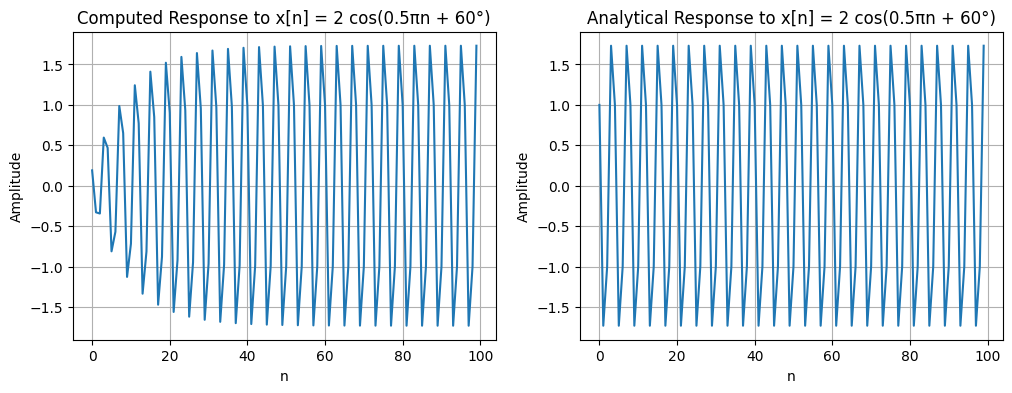

In [ ]:
n = np.arange(100)
x = 2 * np.cos(0.5 * np.pi * n + np.pi / 3)
y_computed = signal.lfilter(num, den, x)
y_analytical = x

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(n, y_computed)
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.title('Computed Response to x[n] = 2 cos(0.5πn + 60°)')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(n, y_analytical)
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.title('Analytical Response to x[n] = 2 cos(0.5πn + 60°)')
plt.grid()
plt.show()

Looking at the steady state response which can be seen from around sample 40 and up, the response computed using python matches the one determined analytically.

## Problem 5.4

## Problem *5.30
Consider a periodic signal

$$
x[n] = \sin(0.1 \pi n) + \frac{1}{3} \sin(0.3 \pi n) + \frac{1}{5} \sin(0.5 \pi n)
$$

For each of the following systems, determine if the system imparts 

(i) no distortion,

(ii) magnitude distortion, and/or 

(iii) phase (or delay) distortion. 

In each case, graph the input and the steady state response for $0 \leq n \leq 60$.

### (a) $h[n] = \{ 1, -2, 3, -4, 0, 4, -3, 2, -1 \}$

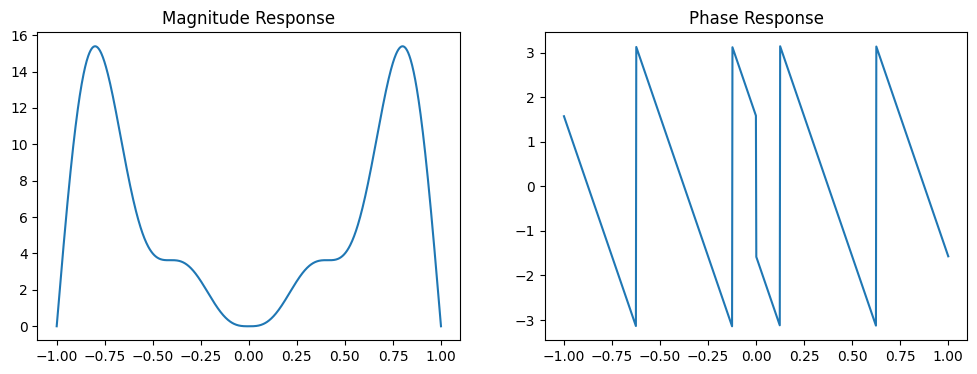

In [41]:
num = [1, -2, 3, -4, 0, 4, -3, 2, -1]
den = [1]
w = np.linspace(-np.pi, np.pi, 1000)
_, H = signal.freqz(num, den, worN=w)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(w/np.pi, np.abs(H))
plt.title("Magnitude Response")

plt.subplot(1, 2, 2)
plt.plot(w / np.pi, np.angle(H))
plt.title("Phase Response")
plt.show()

It can be seen that the magnitude response is not constant and the phase response is not linear, which means that there is both magnitude and phase distortion.

Text(0.5, 1.0, 'Plot of input and steady state response')

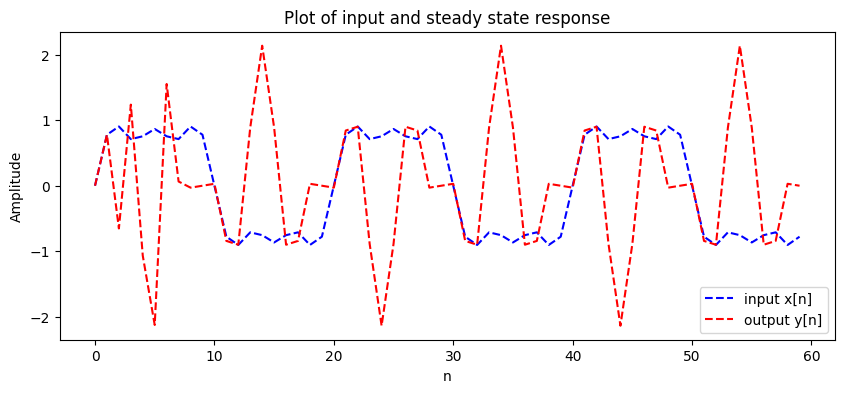

In [ ]:
n = np.arange(60)
x = np.sin(0.1 * np.pi * n) + 1/3 * np.sin(0.3 * np.pi * n) + 1/5 * np.sin(0.5 * np.pi * n)
y_computed = signal.lfilter(num, den, x)

plt.figure(figsize=(10, 4))
plt.plot(n, x, color='b', linestyle='--', label='input x[n]')
plt.plot(n, y_computed, color='r', linestyle='--', label='output y[n]')
plt.legend()
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.title('Plot of input and steady state response')

### (b) $y[n] = 10 x[n - 10]$

The system's transfer function is found as follows

\begin{align*}
Y[z] &= 10 z^{-10} X(z)\\
H[z] = \frac{Y[z]}{X[z]} &= 10 z^{-10}
\end{align*}

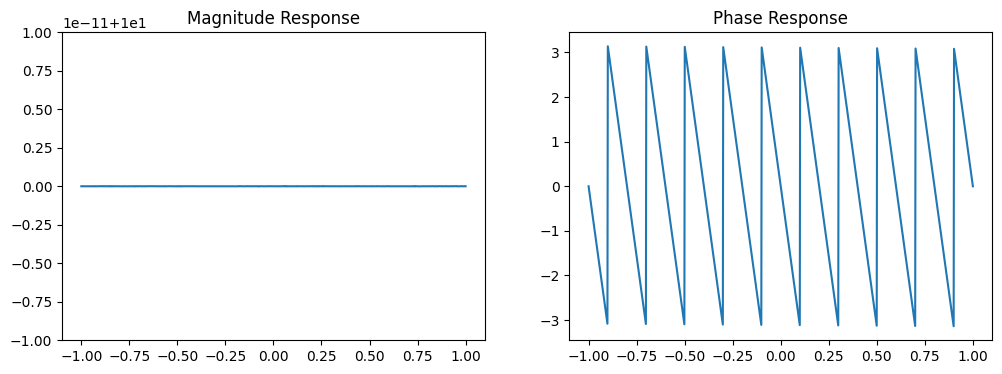

In [43]:
num = np.zeros(11)
num[-1] = 10
den = [1]
w = np.linspace(-np.pi, np.pi, 1000)
_, H = signal.freqz(num, den, worN=w)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(w/np.pi, np.abs(H))
plt.title("Magnitude Response")

plt.subplot(1, 2, 2)
plt.plot(w / np.pi, np.angle(H))
plt.title("Phase Response")
plt.show()

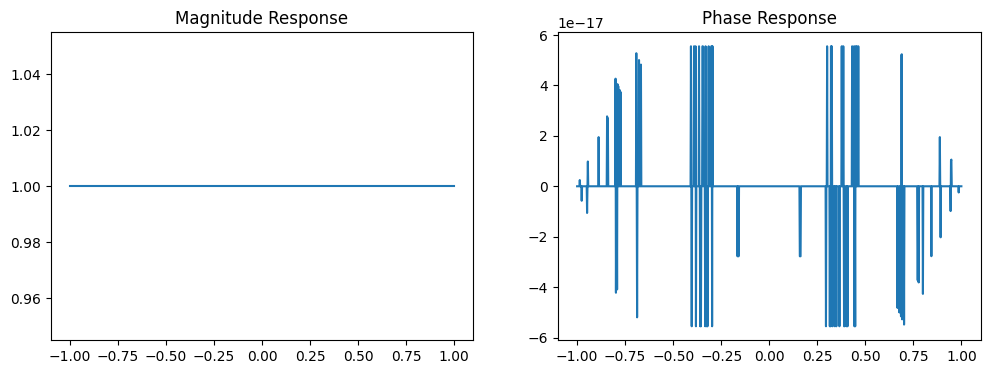

In [60]:
num = [1, 1]
den = [1, 1]
w = np.linspace(-np.pi, np.pi, 1000)
_, H = signal.freqz(num, den, worN=w)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(w/np.pi, np.abs(H))
plt.title("Magnitude Response")

plt.subplot(1, 2, 2)
plt.plot(w / np.pi, np.angle(H))
plt.title("Phase Response")
plt.show()

It can be seen that the magnitude response is constant and the phase response is not linear. Therefore, there is phase distortion but no magnitude distortion.

Text(0.5, 1.0, 'Plot of input and steady state response')

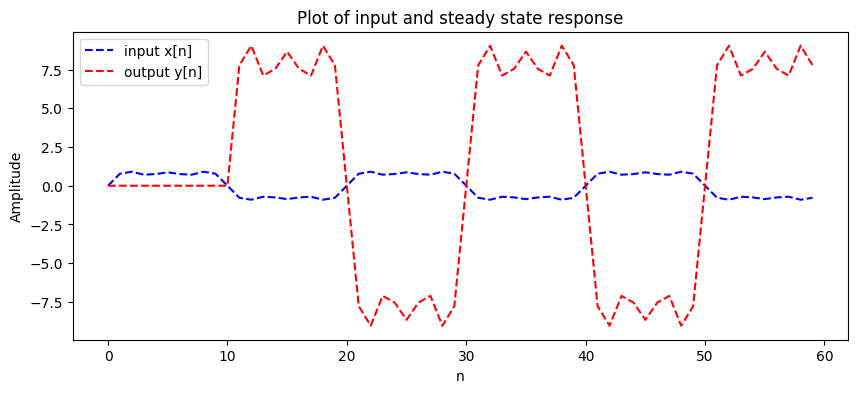

In [44]:
n = np.arange(60)
x = np.sin(0.1 * np.pi * n) + 1/3 * np.sin(0.3 * np.pi * n) + 1/5 * np.sin(0.5 * np.pi * n)
y_computed = signal.lfilter(num, den, x)

plt.figure(figsize=(10, 4))
plt.plot(n, x, color='b', linestyle='--', label='input x[n]')
plt.plot(n, y_computed, color='r', linestyle='--', label='output y[n]')
plt.legend()
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.title('Plot of input and steady state response')

### (c) $H(z) = \frac{1}{9} (1 + 2z^{-1} + 3z^{-2} + 2z^{-3} + z^{-4})$

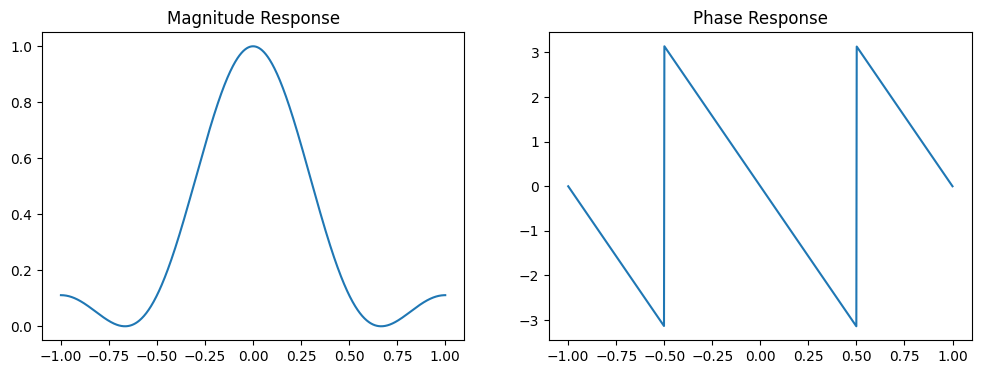

In [45]:
num = [1, 2, 3, 2, 1]
den = [9]
w = np.linspace(-np.pi, np.pi, 1000)
_, H = signal.freqz(num, den, worN=w)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(w/np.pi, np.abs(H))
plt.title("Magnitude Response")

plt.subplot(1, 2, 2)
plt.plot(w / np.pi, np.angle(H))
plt.title("Phase Response")
plt.show()

It can be seen that the magnitude response is not constant and the phase response is not linear, which means that there is both magnitude and phase distortion.

Text(0.5, 1.0, 'Plot of input and steady state response')

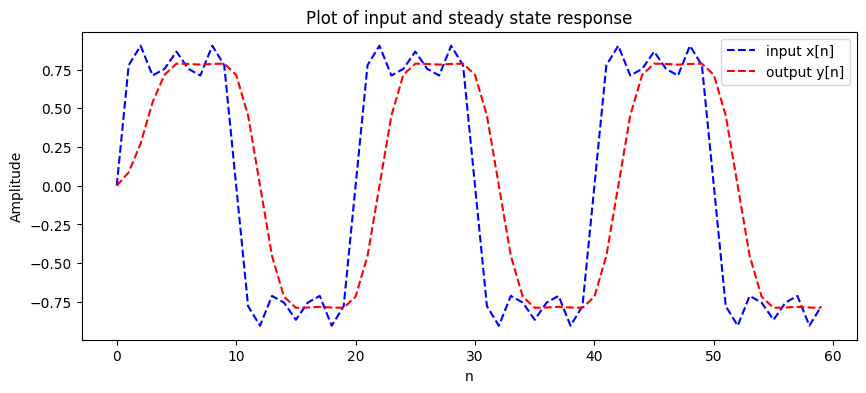

In [46]:
n = np.arange(60)
x = np.sin(0.1 * np.pi * n) + 1/3 * np.sin(0.3 * np.pi * n) + 1/5 * np.sin(0.5 * np.pi * n)
y_computed = signal.lfilter(num, den, x)

plt.figure(figsize=(10, 4))
plt.plot(n, x, color='b', linestyle='--', label='input x[n]')
plt.plot(n, y_computed, color='r', linestyle='--', label='output y[n]')
plt.legend()
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.title('Plot of input and steady state response')

### (d) $h[n] = \{ 1, -1.1756, 1 \}$

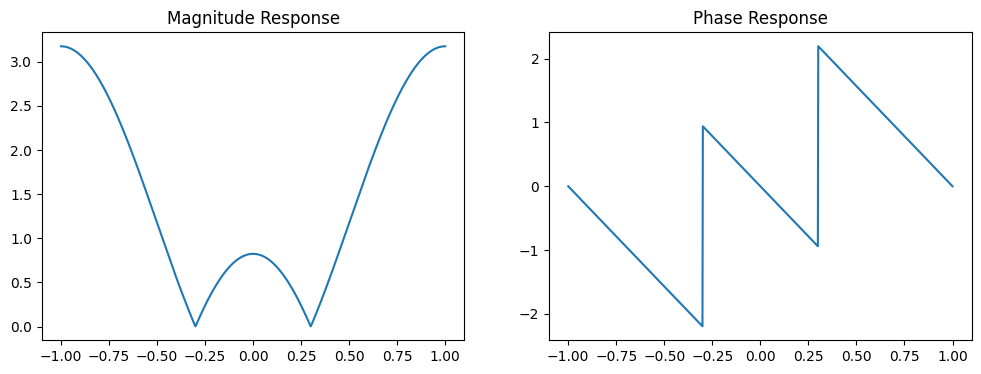

In [47]:
num = [1, -1.1756, 1]
den = [1]
w = np.linspace(-np.pi, np.pi, 1000)
_, H = signal.freqz(num, den, worN=w)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(w/np.pi, np.abs(H))
plt.title("Magnitude Response")

plt.subplot(1, 2, 2)
plt.plot(w / np.pi, np.angle(H))
plt.title("Phase Response")
plt.show()

It can be seen that the magnitude response is not constant and the phase response is not linear, which means that there is both magnitude and phase distortion.

Text(0.5, 1.0, 'Plot of input and steady state response')

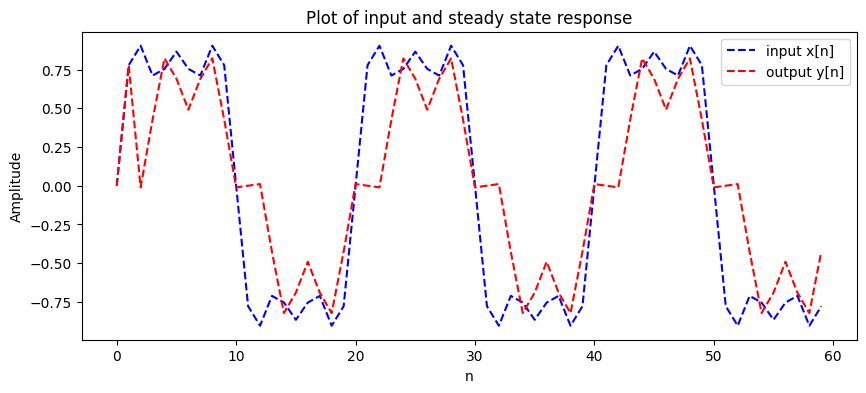

In [48]:
n = np.arange(60)
x = np.sin(0.1 * np.pi * n) + 1/3 * np.sin(0.3 * np.pi * n) + 1/5 * np.sin(0.5 * np.pi * n)
y_computed = signal.lfilter(num, den, x)

plt.figure(figsize=(10, 4))
plt.plot(n, x, color='b', linestyle='--', label='input x[n]')
plt.plot(n, y_computed, color='r', linestyle='--', label='output y[n]')
plt.legend()
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.title('Plot of input and steady state response')

### (e) $H(z) = \frac{1 + 1.778z^{-2} + 3.1605z^{-4}}{1 + 0.5625z^{-2} + 0.3164z^{-4}}$

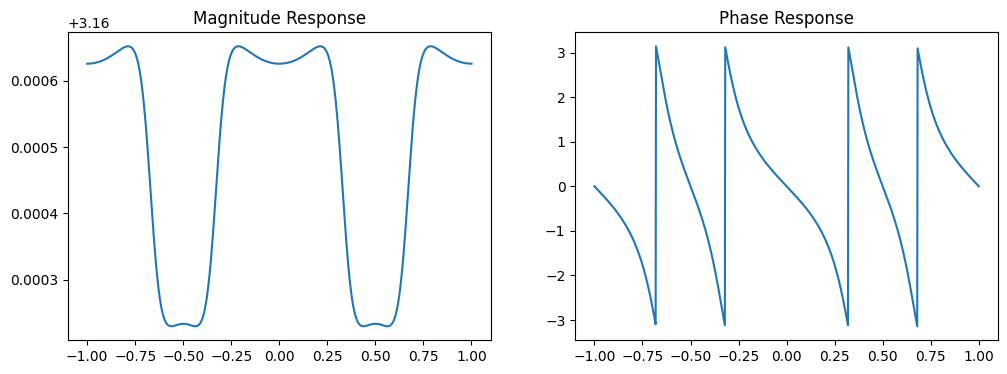

In [49]:
num = [1, 0, 1.778, 0, 3.1605]
den = [1, 0, 0.5625, 0, 0.3164]
w = np.linspace(-np.pi, np.pi, 1000)
_, H = signal.freqz(num, den, worN=w)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(w/np.pi, np.abs(H))
plt.title("Magnitude Response")

plt.subplot(1, 2, 2)
plt.plot(w / np.pi, np.angle(H))
plt.title("Phase Response")
plt.show()

It can be seen that the magnitude response is not constant and the phase response is not linear, which means that there is both magnitude and phase distortion.

Text(0.5, 1.0, 'Plot of input and steady state response')

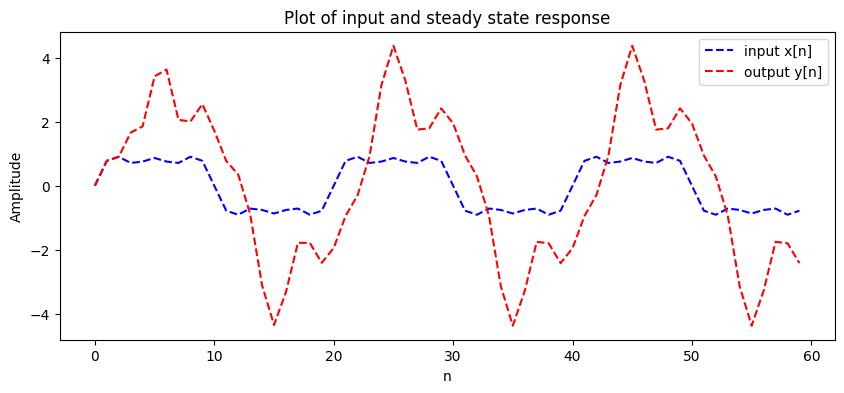

In [50]:
n = np.arange(60)
x = np.sin(0.1 * np.pi * n) + 1/3 * np.sin(0.3 * np.pi * n) + 1/5 * np.sin(0.5 * np.pi * n)
y_computed = signal.lfilter(num, den, x)

plt.figure(figsize=(10, 4))
plt.plot(n, x, color='b', linestyle='--', label='input x[n]')
plt.plot(n, y_computed, color='r', linestyle='--', label='output y[n]')
plt.legend()
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.title('Plot of input and steady state response')

## Problem 5.35(a og b)

## Problem 5.48